# 📏 Linear Regression in Python
##### Machine Learning - Ruben D. Fonnegra


<a href="https://colab.research.google.com/github/rubenfonnegra/machine_learning/blob/master/Sem_05/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> 
<a href="https://github.com/rubenfonnegra/machine_learning/blob/master/Sem_05/linear_regression.ipynb" target="_parent"><img src="https://img.shields.io/badge/%E2%80%8B-Open%20in%20Github-blue?logo=github" alt="Open In Github"/></a> 


Linear regression is a supervised learning method used to predict a continuous numerical value.

### Learning objectives

By the end of this notebook, you will be able to:

- Explain simple and multiple linear regression.
- Interpret the slope and intercept.
- Understand predictions and residuals.
- Explain the least-squares objective.
- Evaluate models using MAE, MSE, RMSE, and \(R^2\).
- Analyze residual plots.
- Compare ordinary, Ridge, and Lasso regression.


### Documentation

- [```LinearRegression``` ](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html?highlight=linear%20regression#sklearn.linear_model.LinearRegression)

---

> **📘 Machine Learning**  
> **Author:** Rubén D. Fonnegra, Ph.D. \
> **Institution:** Institución Universitaria Pascual Bravo  
> © 2026 · Educational use with attribution

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression, load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Core Equation

Simple linear regression predicts:

$$
\hat{y}= mx + b
$$

- $b$: intercept
- $m$: slope
- $x$: input feature
- $\hat{y}$: prediction

In [2]:
intercept = 10
slope = 2.5
x = 4

y_hat = intercept + slope * x
print("Prediction:", y_hat)

Prediction: 20.0


### Create a Synthetic Dataset

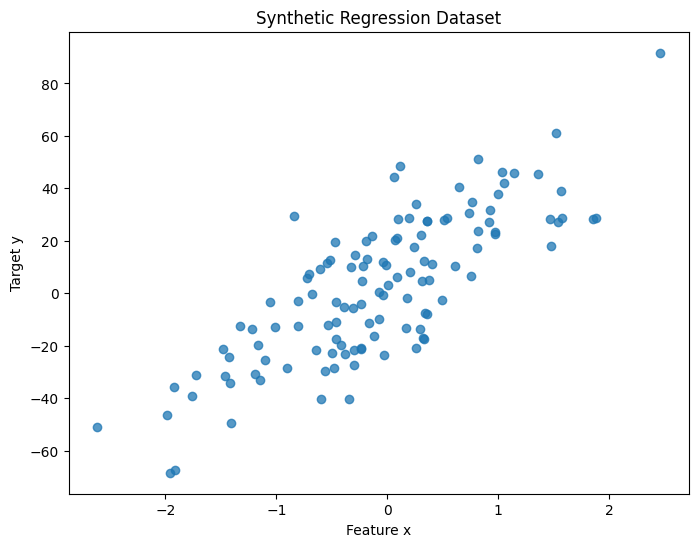

Num samples: 120


In [3]:
X, y = make_regression(
    n_samples=120,
    n_features=1,
    noise=18,
    random_state=42
)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], y, alpha=0.75)
plt.xlabel("Feature x")
plt.ylabel("Target y")
plt.title("Synthetic Regression Dataset")
plt.show()

print("Num samples:", len(X))

### Train the Model

In [5]:
model = LinearRegression()
model.fit( X , y )

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 4.337916552127247
Slope: 24.10109897788304


### Plot the Regression Line

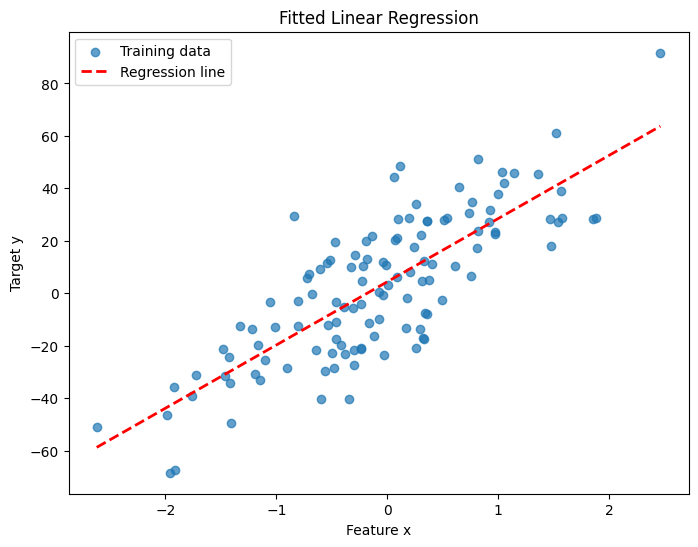

In [8]:
x_line = np.linspace(
    X[:, 0].min(),
    X[:, 0].max(),
    300
).reshape(-1, 1)

y_line = model.predict(x_line )

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], y, alpha=0.7, label="Training data")
plt.plot(x_line[:, 0], y_line, c="r", linewidth=2, linestyle="--", label="Regression line")
plt.xlabel("Feature x")
plt.ylabel("Target y")
plt.title("Fitted Linear Regression")
plt.legend()
plt.show()

### Residuals

A residual is:

$$
e_i=y_i-\hat{y}_i
$$

- Positive residual: prediction was too low.
- Negative residual: prediction was too high.

In [21]:
y_pred = model.predict( X )
residuals = y - y_pred 

results = pd.DataFrame({
    "Observed": y,
    "Predicted": y_pred,
    "Residual": residuals
})

results.head(10)
print(np.sum(residuals**2) / len(y))


282.42469091227287


### Evaluation Metrics

In [16]:
mae = mean_absolute_error( y , y_pred )
mse = mean_squared_error ( y , y_pred )

print(f"MAE:  {mae:.3f}")
print(f"MSE:  {mse:.3f}")

MAE:  13.931
MSE:  282.425


### Observed vs Predicted

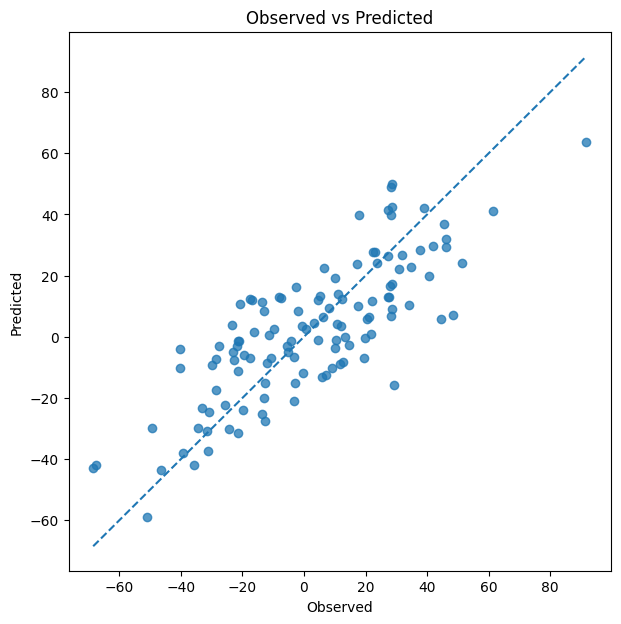

In [17]:
minimum = min(y.min(), y_pred.min())
maximum = max(y.max(), y_pred.max())

plt.figure(figsize=(7, 7))
plt.scatter(y, y_pred, alpha=0.75)
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Observed vs Predicted")
plt.show()

### Residual Plot

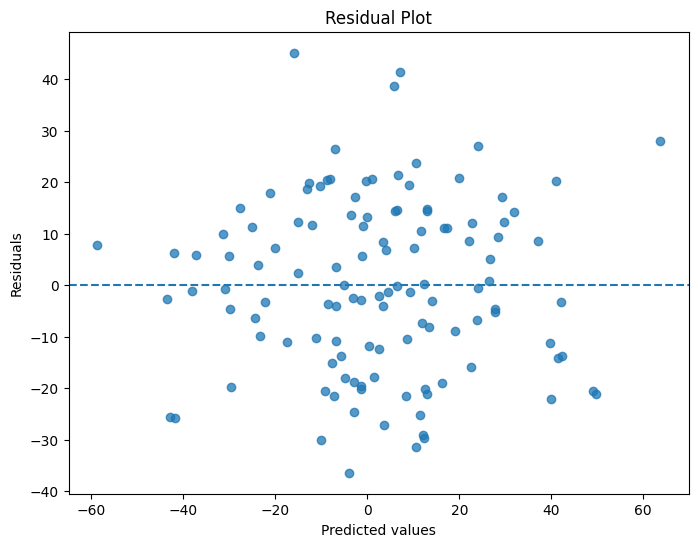

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.75)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### Multiple Linear Regression

With several features:

$$
\hat{y}= m_0 + m_1x_1 + m_2x_2 + \cdots + m_px_p
$$

### Real Dataset: Diabetes

In [23]:
diabetes = load_diabetes(as_frame=True)

X_real = diabetes.data
y_real = diabetes.target

print("Features:", X_real.shape , y_real.shape)
X_real.head()

Features: (442, 10) (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


### Correlation with the Target

In [29]:
df_real = X_real.copy()
df_real["target"] = y_real

df_real.corr(numeric_only=True)["target"].sort_values(ascending=False)

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64

### Train a Multiple Regression Model

In [39]:
multi_model = LinearRegression()
multi_model.fit( X_real , y_real )

yr_pred = multi_model.predict( X_real )

### Evaluate the Real-Data Model

In [30]:
print("MAE:", mean_absolute_error( y_real , yr_pred ))
print("MSE:", mean_squared_error ( y_real , yr_pred )) 

MAE: 64.1395385591764
MSE: 5745.150234568824


### Interpret Coefficients

In [40]:
coef_df = pd.DataFrame({
    "Feature": X_real.columns,
    "Coefficient": multi_model.coef_
})

coef_df["Absolute coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Absolute coefficient", ascending=False)

coef_df

,Feature,Coefficient,Absolute coefficient
4,s1,-792.175639,792.175639
8,s5,751.273700,751.273700
2,bmi,519.845920,519.845920
5,s2,476.739021,476.739021
3,bp,324.384646,324.384646
1,sex,-239.815644,239.815644
7,s4,177.063238,177.063238
6,s3,101.043268,101.043268
9,s6,67.626692,67.626692
0,age,-10.009866,10.009866


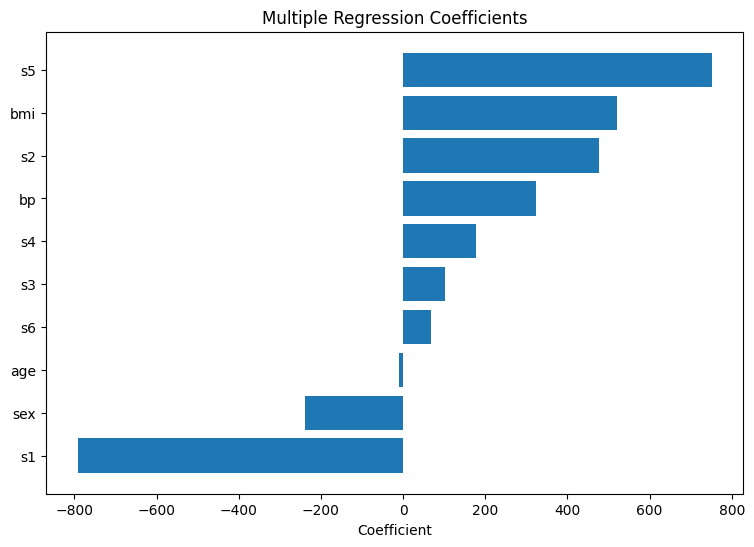

In [41]:
plot_df = coef_df.sort_values("Coefficient")

plt.figure(figsize=(9, 6))
plt.barh(plot_df["Feature"], plot_df["Coefficient"])
plt.xlabel("Coefficient")
plt.title("Multiple Regression Coefficients")
plt.show()

### Residual Analysis

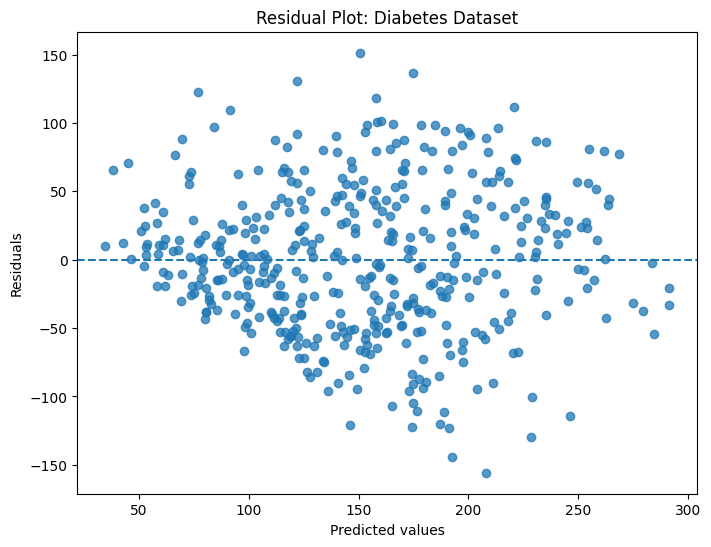

In [43]:
real_residuals = y_real - yr_pred 

plt.figure(figsize=(8, 6))
plt.scatter(yr_pred, real_residuals, alpha=0.75)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residual Plot: Diabetes Dataset")
plt.show()

### Main Assumptions

- Approximate linearity
- Independent observations
- Limited multicollinearity

### Nonlinear Relationship Example

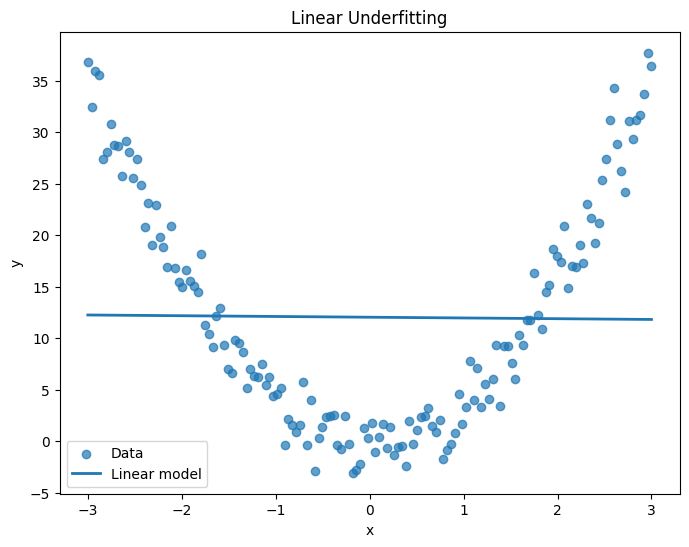

In [44]:
rng = np.random.default_rng(42)

X_curve = np.linspace(-3, 3, 150).reshape(-1, 1)
y_curve = 4 * X_curve[:, 0]**2 + rng.normal(0, 2.5, 150)

linear_curve_model = LinearRegression()
linear_curve_model.fit( X_curve , y_curve )

linear_curve_pred = linear_curve_model.predict( X_curve )

plt.figure(figsize=(8, 6))
plt.scatter(X_curve[:, 0], y_curve, alpha=0.7, label="Data")
plt.plot(X_curve[:, 0], linear_curve_pred, linewidth=2, label="Linear model")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Underfitting")
plt.legend()
plt.show()

### Polynomial Features

(150, 2)


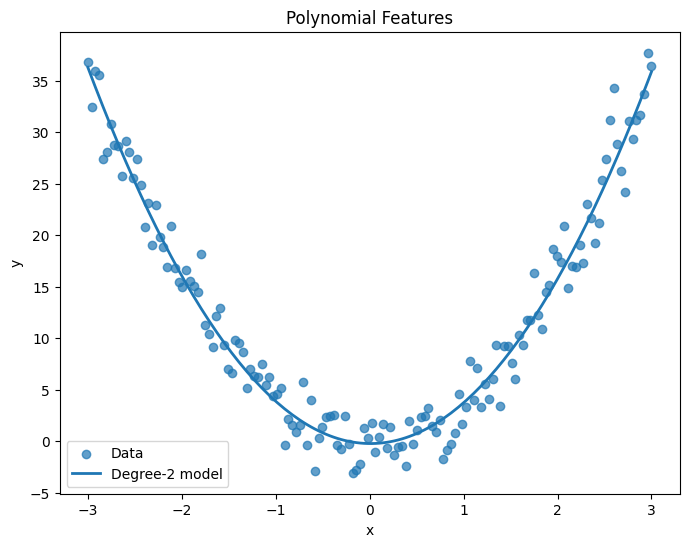

In [52]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)
poly_model = LinearRegression()

X_poly = poly_features.fit_transform(X_curve)
print(X_poly.shape)
poly_model.fit( X_poly , y_curve )
poly_pred = poly_model.predict( X_poly )

plt.figure(figsize=(8, 6))
plt.scatter(X_curve, y_curve, alpha=0.7, label="Data")
plt.plot(X_curve, poly_pred, linewidth=2, label="Degree-2 model")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial Features")
plt.legend()
plt.show()

### Practice Exercises

#### Exercise 1
Calculate a prediction manually using the learned slope and intercept.

In [ ]:
# Your code here

#### Exercise 2
Calculate MAE, MSE, RMSE, and \(R^2\) manually.

In [ ]:
# Your code here

#### Exercise 3
Generate datasets with different noise values and compare performance.

In [ ]:
# Your code here

#### Exercise 4
Compare one-feature, three-feature, and all-feature models.

In [ ]:
# Your code here

---

## 📄 Attribution

This notebook was developed by **Rubén D. Fonnegra** as educational material for Machine Learning courses at **Institución Universitaria Pascual Bravo**.
You may use, share, and adapt this material for educational purposes, provided that appropriate credit is given to the original author.

**Suggested citation:**
> Fonnegra Tarazona, R. D. (2026). *Linear Regression: Machine Learning Notebook*. Institución Universitaria Pascual Bravo.